In [ ]:
# ── Cell 1: Install & Mount ────────────────────────────────────
# !pip install sympy==1.12

from google.colab import drive
drive.mount('/content/drive')

import sys
sys.path.append('/content/drive/MyDrive/MLP')

Mounted at /content/drive


In [ ]:
# ── Cell 2: Imports ────────────────────────────────────────────
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, WeightedRandomSampler
from torchvision import transforms
from torchvision.models import resnet50, ResNet50_Weights
import torchvision.transforms.functional as TF

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, cohen_kappa_score
)
from tqdm.notebook import tqdm

from dataset import APTOSDataset


In [ ]:
# ── Cell 3: Paths ───────────────────────────────────────────────
APTOS_CSV       = "/content/drive/MyDrive/MLP/aptos_dataset/train.csv"
APTOS_IMAGE_DIR = "/content/drive/MyDrive/MLP/aptos_dataset"

# ✅ Unique filenames — will never overwrite other runs
CHECKPOINT_PATH = "/content/drive/MyDrive/MLP/dr_resnet50_checkpoint_batch32_ep10.pth"
BEST_MODEL_PATH = "/content/drive/MyDrive/MLP/dr_resnet50_best_batch32_ep10.pth"

In [ ]:
# ── Cell 4: Hyperparameters ─────────────────────────────────────
NUM_EPOCHS   = 10
BATCH_SIZE   = 32
LR           = 1e-4
WEIGHT_DECAY = 1e-5
RANDOM_SEED  = 78


In [ ]:
# ── Cell 5: SquarePad ───────────────────────────────────────────
class SquarePad:
    """Pads image to square before resizing, preserving aspect ratio."""
    def __call__(self, image):
        w, h = image.size
        max_wh = max(w, h)
        hp = (max_wh - w) // 2
        vp = (max_wh - h) // 2
        padding = [hp, vp, max_wh - w - hp, max_wh - h - vp]
        return TF.pad(image, padding, fill=0, padding_mode='constant')

print("✅ SquarePad ready")

✅ SquarePad ready


In [ ]:
# ── Cell 6: Ordinal Label Helper ────────────────────────────────
def make_thresholds(label):
    """Convert DR grade to ordinal threshold vector. e.g. 2 -> [1,1,0,0]"""
    return [1 if label >= i else 0 for i in range(1, 5)]

In [ ]:
# ── Cell 7: Transforms ──────────────────────────────────────────
transform_train = transforms.Compose([
    SquarePad(),
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(10),
    transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 1.0)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

transform_val = transforms.Compose([
    SquarePad(),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

In [ ]:
# ── Cell 8: Load & Filter Dataset ──────────────────────────────
df = pd.read_csv(APTOS_CSV)

df = df[df['id_code'].apply(
    lambda x: os.path.exists(os.path.join(APTOS_IMAGE_DIR, x + ".png"))
)].reset_index(drop=True)

print(f"Dataset size after filtering: {df.shape[0]}")

df['thresholds'] = df['diagnosis'].apply(make_thresholds)

Dataset size after filtering: 3662


In [ ]:
# ── Cell 9: Train / Val Split ───────────────────────────────────
train_df, val_df = train_test_split(
    df,
    test_size=0.2,
    stratify=df['diagnosis'],
    random_state=RANDOM_SEED
)

print(f"Train: {train_df.shape[0]}  Val: {val_df.shape[0]}")

class_counts_tr = train_df['diagnosis'].value_counts().sort_index().values
class_counts_vl = val_df['diagnosis'].value_counts().sort_index().values
print(f"Train class counts: {class_counts_tr}")
print(f"Val class counts:   {class_counts_vl}")

Train: 2929  Val: 733
Train class counts: [1444  296  799  154  236]
Val class counts:   [361  74 200  39  59]


In [ ]:
# ── Cell 10: Datasets & Loaders ─────────────────────────────────
train_dataset = APTOSDataset(train_df, APTOS_IMAGE_DIR, transform_train)
val_dataset   = APTOSDataset(val_df,   APTOS_IMAGE_DIR, transform_val)

# Weighted sampler to handle class imbalance
class_weights  = 1.0 / class_counts_tr
sample_weights = torch.tensor(
    train_df['diagnosis'].map(
        {i: class_weights[i] for i in range(len(class_weights))}
    ).values,
    dtype=torch.float
)

sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False)


Images shape: torch.Size([32, 3, 224, 224])
Labels shape: torch.Size([32, 4])


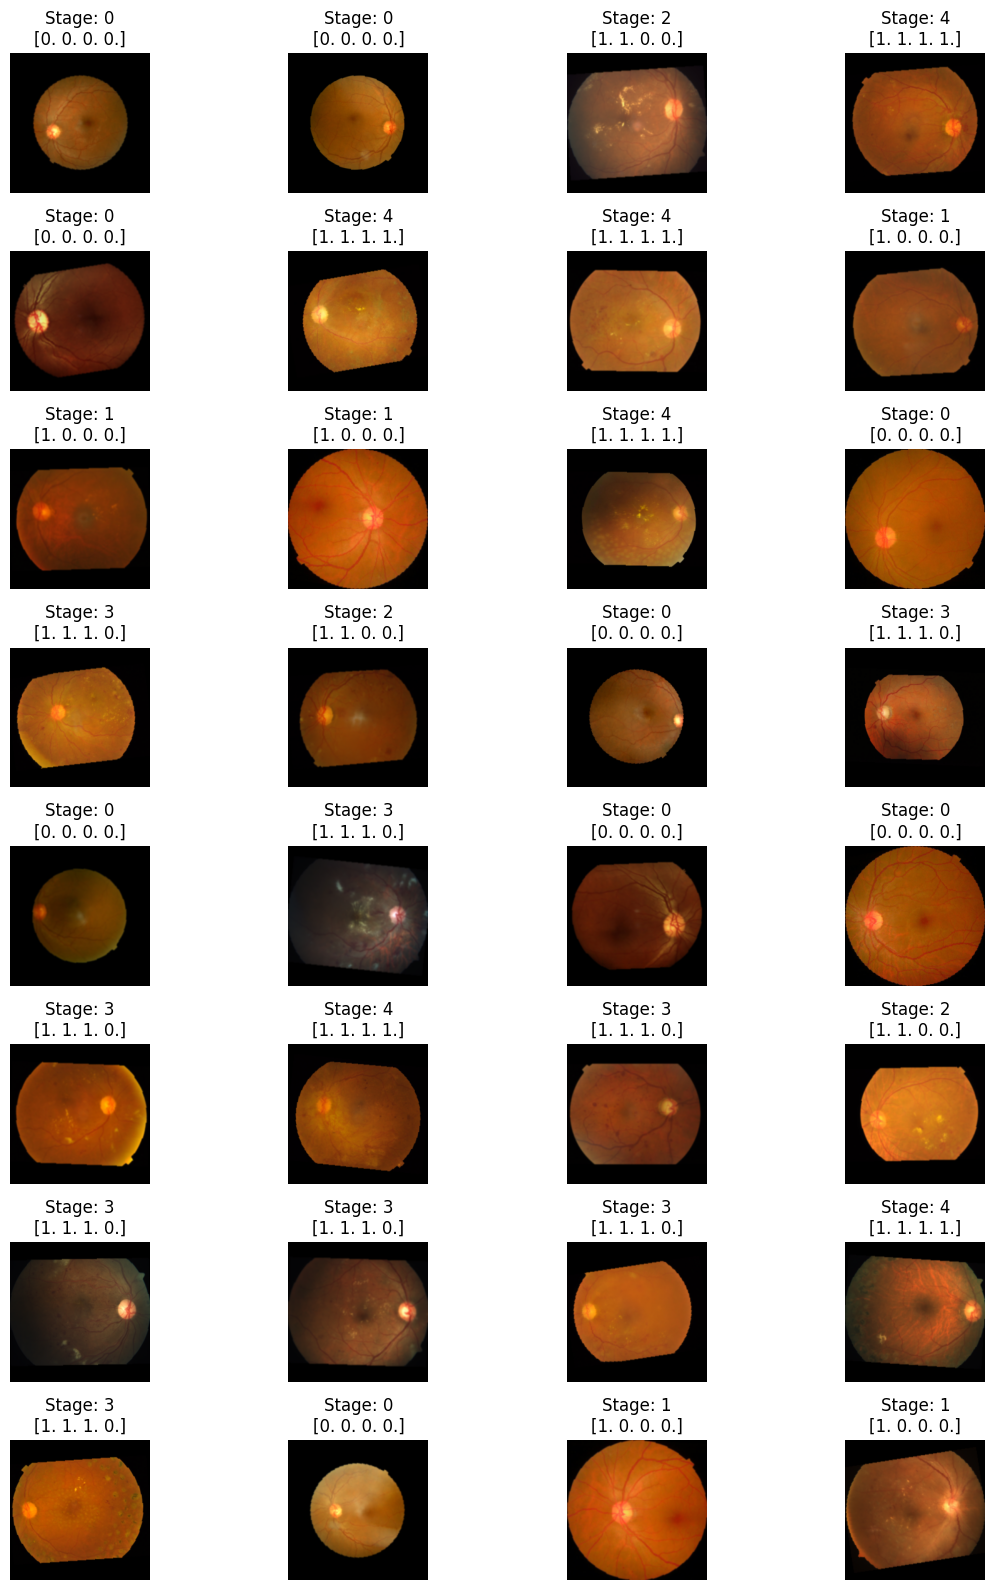

In [ ]:
# ── Cell 11: Visualise a Batch ──────────────────────────────────
images, labels = next(iter(train_loader))
print("Images shape:", images.shape)
print("Labels shape:", labels.shape)

mean = np.array([0.485, 0.456, 0.406])
std  = np.array([0.229, 0.224, 0.225])

fig, axes = plt.subplots(8, 4, figsize=(12, 16))
axes = axes.flatten()

for i in range(len(images)):
    img = images[i].cpu().numpy().transpose(1, 2, 0)
    img = std * img + mean
    img = np.clip(img, 0, 1)
    axes[i].imshow(img)
    stage = int(labels[i].cpu().numpy().sum())
    axes[i].set_title(f"Stage: {stage}\n{labels[i].cpu().numpy()}")
    axes[i].axis('off')

plt.tight_layout()
plt.show()


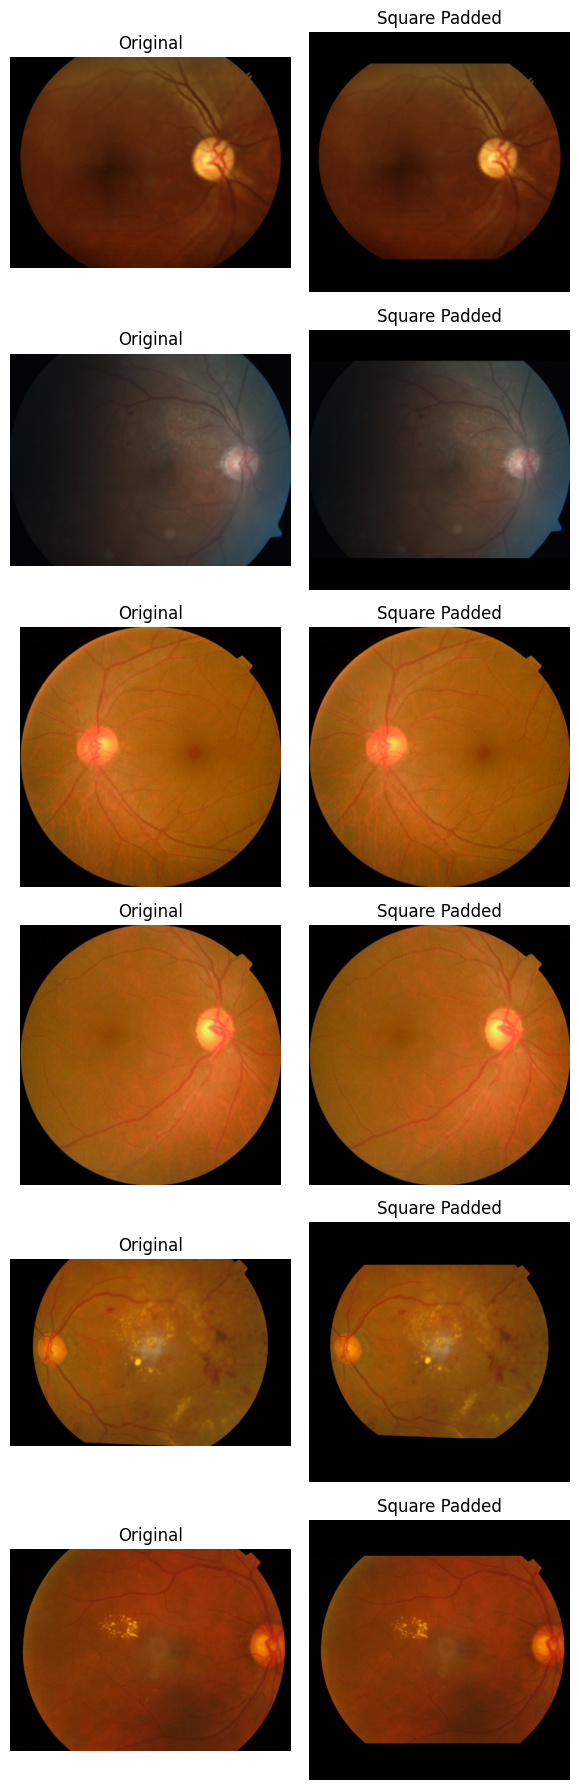

In [ ]:
# ── Cell 12: Visualise SquarePad ────────────────────────────────
from PIL import Image

square_pad    = SquarePad()
sample_images = df['id_code'].sample(6).values

fig, axes = plt.subplots(6, 2, figsize=(6, 18))

for i, img_id in enumerate(sample_images):
    path   = os.path.join(APTOS_IMAGE_DIR, img_id + ".png")
    img    = Image.open(path).convert("RGB")
    padded = square_pad(img)

    axes[i, 0].imshow(img)
    axes[i, 0].set_title("Original")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(padded)
    axes[i, 1].set_title("Square Padded")
    axes[i, 1].axis("off")

plt.tight_layout()
plt.show()

In [ ]:
# ── Cell 13: Build Model ─────────────────────────────────────────
device  = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

weights = ResNet50_Weights.DEFAULT
model   = resnet50(weights=weights)
model.fc = nn.Linear(model.fc.in_features, 4)
model   = model.to(device)

Using device: cpu
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 127MB/s]


In [ ]:
# ── Cell 14: Stage-Weighted Loss ────────────────────────────────
stage_counts  = train_df['diagnosis'].value_counts().sort_index()
stage_weights = 1.0 / stage_counts
stage_weights = stage_weights / stage_weights.sum()

print("Stage weights:")
print(stage_weights)

threshold_weights = torch.tensor([
    stage_weights[1:].sum(),  # DR ≥ 1
    stage_weights[2:].sum(),  # DR ≥ 2
    stage_weights[3:].sum(),  # DR ≥ 3
    stage_weights[4]          # DR ≥ 4
]).float().to(device)

criterion = nn.BCEWithLogitsLoss(pos_weight=threshold_weights)


Stage weights:
diagnosis
0    0.043139
1    0.210448
2    0.077963
3    0.404498
4    0.263952
Name: count, dtype: float64


In [ ]:
# ── Cell 15: Optimizer & Scheduler ──────────────────────────────
optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=3
)
print("Optimizer and scheduler ready.")


Optimizer and scheduler ready.


In [ ]:
# ── Cell 16: Sanity Check Batch ─────────────────────────────────
images, labels = next(iter(train_loader))
print("Images:", images.shape)   # [32, 3, 224, 224]
print("Labels:", labels.shape)   # [32, 4]
print("Sample label:", labels[0])

Images: torch.Size([32, 3, 224, 224])
Labels: torch.Size([32, 4])
Sample label: tensor([1., 1., 1., 0.])


In [ ]:
# ── Cell 17: Resume from Checkpoint (run if resuming) ──────────
# ✅ Only run this cell if Colab disconnected and you need to resume.
# Skip it if starting fresh.

if os.path.exists(CHECKPOINT_PATH):
    print(f"Resuming from checkpoint: {CHECKPOINT_PATH}")
    checkpoint    = torch.load(CHECKPOINT_PATH, map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    start_epoch   = checkpoint['epoch'] + 1
    best_val_loss = checkpoint.get('best_val_loss', float('inf'))  # ✅ restored
    train_losses  = checkpoint.get('train_losses', [])              # ✅ restored
    val_losses    = checkpoint.get('val_losses', [])                # ✅ restored
    print(f"Resuming from epoch {start_epoch}")
    print(f"Best val loss so far: {best_val_loss:.4f}")
else:
    print("No checkpoint found — starting fresh.")
    start_epoch   = 0
    best_val_loss = float('inf')
    train_losses  = []
    val_losses    = []


No checkpoint found — starting fresh.


In [ ]:
# ── Cell 18: Training Loop ───────────────────────────────────────
# ✅ If starting fresh (not resuming), initialise these here
# Comment this out if you ran Cell 17 above
start_epoch   = 0
best_val_loss = float('inf')
train_losses  = []
val_losses    = []

for epoch in range(start_epoch, NUM_EPOCHS):

    # --- Train ---
    model.train()
    running_loss = 0.0

    for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS} [Train]"):
        images = images.to(device)
        labels = labels.to(device).float()

        optimizer.zero_grad()
        outputs = model(images)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

    epoch_train_loss = running_loss / len(train_loader.dataset)
    train_losses.append(epoch_train_loss)

    # --- Validate ---
    model.eval()
    val_running_loss = 0.0

    with torch.no_grad():
        for images, labels in tqdm(val_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS} [Val]"):
            images = images.to(device)
            labels = labels.to(device).float()
            outputs = model(images)
            loss    = criterion(outputs, labels)
            val_running_loss += loss.item() * images.size(0)

    epoch_val_loss = val_running_loss / len(val_loader.dataset)
    val_losses.append(epoch_val_loss)

    print(f"\nEpoch {epoch+1}/{NUM_EPOCHS}")
    print(f"  Train Loss: {epoch_train_loss:.4f}")
    print(f"  Val Loss:   {epoch_val_loss:.4f}")

    scheduler.step(epoch_val_loss)

    # --- Save checkpoint (✅ now saves best_val_loss + full loss history) ---
    torch.save({
        'epoch':                epoch,
        'model_state_dict':     model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'train_loss':           epoch_train_loss,
        'val_loss':             epoch_val_loss,
        'best_val_loss':        best_val_loss,   # ✅ fixed
        'train_losses':         train_losses,     # ✅ fixed
        'val_losses':           val_losses,       # ✅ fixed
    }, CHECKPOINT_PATH)
    print(f"  Checkpoint saved → {CHECKPOINT_PATH}")

    # --- Save best model ---
    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        torch.save(model.state_dict(), BEST_MODEL_PATH)
        print(f"  ✅ Best model updated (val loss: {best_val_loss:.4f}) → {BEST_MODEL_PATH}")

print("\n🏁 Training complete!")
print(f"Best val loss achieved: {best_val_loss:.4f}")

Epoch 1/10 [Train]:   0%|          | 0/92 [00:00<?, ?it/s]

Epoch 1/10 [Val]:   0%|          | 0/23 [00:00<?, ?it/s]


Epoch 1/10
  Train Loss: 0.3059
  Val Loss:   0.1535
  Checkpoint saved → /content/drive/MyDrive/MLP/dr_resnet50_checkpoint_batch32_ep10.pth
  ✅ Best model updated (val loss: 0.1535) → /content/drive/MyDrive/MLP/dr_resnet50_best_batch32_ep10.pth


Epoch 2/10 [Train]:   0%|          | 0/92 [00:00<?, ?it/s]

Epoch 2/10 [Val]:   0%|          | 0/23 [00:00<?, ?it/s]

...

Epoch 9/10 [Val]:   0%|          | 0/23 [00:00<?, ?it/s]


Epoch 9/10
  Train Loss: 0.0526
  Val Loss:   0.1338
  Checkpoint saved → /content/drive/MyDrive/MLP/dr_resnet50_checkpoint_batch32_ep10.pth


Epoch 10/10 [Train]:   0%|          | 0/92 [00:00<?, ?it/s]

Epoch 10/10 [Val]:   0%|          | 0/23 [00:00<?, ?it/s]


Epoch 10/10
  Train Loss: 0.0447
  Val Loss:   0.1291
  Checkpoint saved → /content/drive/MyDrive/MLP/dr_resnet50_checkpoint_batch32_ep10.pth

🏁 Training complete!
Best val loss achieved: 0.1132


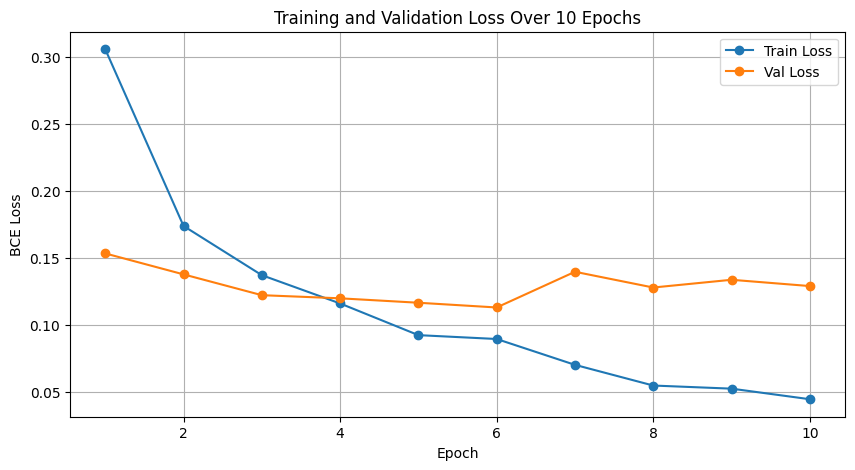

Loss plot saved to Drive


In [ ]:
# ── Cell 19: Loss Plot ───────────────────────────────────────────
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(train_losses)+1), train_losses, label='Train Loss', marker='o')
plt.plot(range(1, len(val_losses)+1),   val_losses,   label='Val Loss',   marker='o')
plt.title('Training and Validation Loss Over 10 Epochs')
plt.xlabel('Epoch')
plt.ylabel('BCE Loss')
plt.legend()
plt.grid(True)
plt.savefig("/content/drive/MyDrive/MLP/dr_resnet50_loss_plot_batch32_ep10.png", dpi=150)
plt.show()
print("Loss plot saved to Drive")


In [ ]:
# ── Cell 20: Load Best Model for Evaluation ─────────────────────
# ✅ Always load the best checkpoint — never evaluate in-memory weights
model.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=device))
model.eval()
print(f"✅ Best model loaded from {BEST_MODEL_PATH}")

✅ Best model loaded from /content/drive/MyDrive/MLP/dr_resnet50_best_batch32_ep10.pth


In [ ]:
# ── Cell 21: Ordinal Prediction Decoding ────────────────────────
def decode_ordinal_predictions(logits):
    probs = torch.sigmoid(logits)
    preds = (probs > 0.5).int()
    return preds.sum(dim=1)

In [ ]:
# ── Cell 22: APTOS Validation Predictions ───────────────────────
all_preds, all_labels = [], []

with torch.no_grad():
    for images, labels in tqdm(val_loader, desc="APTOS Validation"):
        images = images.to(device)
        logits = model(images)
        preds  = decode_ordinal_predictions(logits).cpu().numpy()
        true   = labels.numpy().sum(axis=1)
        all_preds.extend(preds)
        all_labels.extend(true)

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

APTOS Validation:   0%|          | 0/23 [00:00<?, ?it/s]

In [31]:
# ── Cell 23: Overall Metrics ─────────────────────────────────────
acc       = accuracy_score(all_labels, all_preds)
precision = precision_score(all_labels, all_preds, average='macro', zero_division=0)
recall    = recall_score(all_labels, all_preds, average='macro', zero_division=0)
f1        = f1_score(all_labels, all_preds, average='macro', zero_division=0)
qwk       = cohen_kappa_score(all_labels, all_preds, weights='quadratic')

print("APTOS Validation — Overall Metrics")
print("─" * 35)
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"QWK      : {qwk:.4f}")

APTOS Validation — Overall Metrics
───────────────────────────────────
Accuracy : 0.7858
Precision: 0.6629
Recall   : 0.6426
F1 Score : 0.6110
QWK      : 0.8967


In [32]:
# ── Cell 24: Stage-Wise Accuracy ─────────────────────────────────
cm = confusion_matrix(all_labels, all_preds)

print("\nStage-wise Accuracy")
print("─" * 35)
for stage in range(5):
    correct = cm[stage, stage]
    total   = cm[stage].sum()
    acc_s   = correct / total if total > 0 else 0
    print(f"Stage {stage}: {acc_s:.4f} ({correct}/{total})")


Stage-wise Accuracy
───────────────────────────────────
Stage 0: 0.9917 (358/361)
Stage 1: 0.7297 (54/74)
Stage 2: 0.6300 (126/200)
Stage 3: 0.6410 (25/39)
Stage 4: 0.2203 (13/59)


In [ ]:
# ── Cell 25: Confusion Matrix ────────────────────────────────────
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(7, 6))
sns.heatmap(cm_normalized, annot=True, cmap="Blues", fmt=".2f",
            xticklabels=["0","1","2","3","4"],
            yticklabels=["0","1","2","3","4"])
plt.xlabel("Predicted Stage")
plt.ylabel("True Stage")
plt.title(f"APTOS Validation — Confusion Matrix\nQWK: {qwk:.4f}")
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/MLP/dr_resnet50_aptos_cm_batch32_ep10.png", dpi=150)
plt.show()

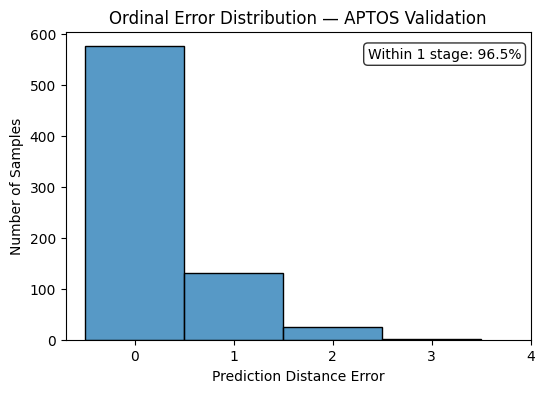

In [ ]:
# ── Cell 26: Ordinal Error Distribution ─────────────────────────
errors = np.abs(all_labels - all_preds)

plt.figure(figsize=(6, 4))
sns.histplot(errors, bins=np.arange(0, 6) - 0.5, discrete=True)
plt.xlabel("Prediction Distance Error")
plt.ylabel("Number of Samples")
plt.title("Ordinal Error Distribution — APTOS Validation")
plt.xticks(range(5))
within_1 = (errors <= 1).mean() * 100
plt.text(0.98, 0.95, f'Within 1 stage: {within_1:.1f}%',
         transform=plt.gca().transAxes, ha='right', va='top',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
plt.show()